In [3]:
import pandas as pd
import numpy as np

# Load the main training data (make sure the csv is in the same directory as your notebook)
print("Loading data...")
df = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')
# 1. Check the scale of the data (rows, columns)
print(f"Dataset shape: {df.shape}")

# 2. Look at the first 5 rows to see what alternative data looks like
display(df.head())

# 3. Check the imbalance of our target variable 
# (TARGET: 1 = client with payment difficulties, 0 = all other cases)
print("\nTarget Variable Distribution:")
print(df['TARGET'].value_counts(normalize=True) * 100)

Loading data...
Dataset shape: (307511, 122)


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0



Target Variable Distribution:
TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [4]:
# 1. Identify Missing Data
# Let's see the top 10 columns that are missing the most information
print("Top 10 columns with missing values (by percentage):")
missing_data = df.isnull().sum() / len(df) * 100
print(missing_data.sort_values(ascending=False).head(10))

# 2. Identify Categorical (Text) Data
# Let's count how many columns contain text instead of numbers
categorical_cols = df.select_dtypes(include=['object']).columns
print(f"\nNumber of categorical (text) columns: {len(categorical_cols)}")
print(f"Here are a few of them: {list(categorical_cols)[:5]}")

Top 10 columns with missing values (by percentage):
COMMONAREA_AVG              69.872297
COMMONAREA_MODE             69.872297
COMMONAREA_MEDI             69.872297
NONLIVINGAPARTMENTS_MEDI    69.432963
NONLIVINGAPARTMENTS_MODE    69.432963
NONLIVINGAPARTMENTS_AVG     69.432963
FONDKAPREMONT_MODE          68.386172
LIVINGAPARTMENTS_AVG        68.354953
LIVINGAPARTMENTS_MEDI       68.354953
LIVINGAPARTMENTS_MODE       68.354953
dtype: float64

Number of categorical (text) columns: 16
Here are a few of them: ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE']


In [5]:
# 1. Drop columns missing more than 60% of their data
threshold = 60
missing_percentages = df.isnull().sum() / len(df) * 100
cols_to_drop = missing_percentages[missing_percentages > threshold].index
df_cleaned = df.drop(columns=cols_to_drop)
print(f"Dropped {len(cols_to_drop)} columns with > {threshold}% missing data.")

# 2. Fill the remaining missing numeric values with the median
# (We use median instead of mean because it is less affected by extreme outliers)
numeric_cols = df_cleaned.select_dtypes(include=['number']).columns
df_cleaned[numeric_cols] = df_cleaned[numeric_cols].fillna(df_cleaned[numeric_cols].median())

# 3. One-Hot Encode the 16 categorical (text) columns into 1s and 0s
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

# Let's see what our data looks like now!
print(f"\nNew dataset shape after cleaning and encoding: {df_encoded.shape}")

Dropped 17 columns with > 60% missing data.

New dataset shape after cleaning and encoding: (307511, 211)


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Separate the Features (X) from the Target (y)
# We also drop 'SK_ID_CURR' because an ID number doesn't predict default risk
X = df_encoded.drop(columns=['TARGET', 'SK_ID_CURR'])
y = df_encoded['TARGET']

# 2. Split the data (80% for training, 20% for testing)
# 'stratify=y' is crucial here: it ensures that the 92/8 imbalance 
# is perfectly maintained in both the training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scale the Features for PyTorch
scaler = StandardScaler()
# We 'fit' the scaler ONLY on the training data to prevent data leakage,
# then we transform both the training and testing sets.
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training data shape: {X_train_scaled.shape}")
print(f"Testing data shape: {X_test_scaled.shape}")

Training data shape: (246008, 209)
Testing data shape: (61503, 209)


In [7]:
import torch
import torch.nn as nn

# 1. Convert NumPy arrays to PyTorch Tensors
# Neural networks require specific data types (float32) and shapes
X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1, 1)

print("Data successfully converted to PyTorch Tensors!")

# 2. Define the Neural Network Architecture
class CreditScoringModel(nn.Module):
    def __init__(self, input_size):
        super(CreditScoringModel, self).__init__()
        
        # First hidden layer: takes the 209 features and expands to 128 nodes
        self.layer1 = nn.Linear(input_size, 128)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3) # Randomly turns off 30% of neurons to prevent overfitting
        
        # Second hidden layer: narrows down to 64 nodes
        self.layer2 = nn.Linear(128, 64)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        # Output layer: condenses down to 1 single prediction node
        self.output_layer = nn.Linear(64, 1)
        self.sigmoid = nn.Sigmoid() # Squeezes output to a probability between 0 and 1

    def forward(self, x):
        # Define how data passes through the network
        x = self.relu1(self.layer1(x))
        x = self.dropout1(x)
        x = self.relu2(self.layer2(x))
        x = self.dropout2(x)
        x = self.sigmoid(self.output_layer(x))
        return x

# 3. Instantiate the model
# We pass 209 because that is our exact number of features
model = CreditScoringModel(input_size=X_train_tensor.shape[1])
print("\nModel Architecture:")
print(model)

Data successfully converted to PyTorch Tensors!

Model Architecture:
CreditScoringModel(
  (layer1): Linear(in_features=209, out_features=128, bias=True)
  (relu1): ReLU()
  (dropout1): Dropout(p=0.3, inplace=False)
  (layer2): Linear(in_features=128, out_features=64, bias=True)
  (relu2): ReLU()
  (dropout2): Dropout(p=0.3, inplace=False)
  (output_layer): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)


In [8]:
import torch.optim as optim
import torch.nn as nn

# 1. Define the Grader (Loss Function) and Learner (Optimizer)
# BCE stands for Binary Cross Entropy (used for Yes/No predictions)
criterion = nn.BCELoss() 
# Adam is a very popular and efficient optimizer
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 2. Set up the Training Loop
epochs = 10
batch_size = 1024

print("Starting the study session...\n")

for epoch in range(epochs):
    model.train() # Make sure the brain is in 'learning mode'
    epoch_loss = 0
    
    # Process the data in small batches so your computer doesn't freeze
    for i in range(0, len(X_train_tensor), batch_size):
        batch_X = X_train_tensor[i:i+batch_size]
        batch_y = y_train_tensor[i:i+batch_size]
        
        # Step A: Clear out the old adjustments from the last guess
        optimizer.zero_grad()
        
        # Step B: Make a guess
        predictions = model(batch_X)
        
        # Step C: The Grader checks how wrong the guess was
        loss = criterion(predictions, batch_y)
        
        # Step D: Figure out exactly which brain connections caused the error
        loss.backward()
        
        # Step E: The Learner tweaks the connections to fix the error
        optimizer.step()
        
        epoch_loss += loss.item()
        
    # Calculate the average error for this whole round
    avg_loss = epoch_loss / (len(X_train_tensor) / batch_size)
    print(f"Epoch [{epoch+1}/{epochs}] - Error (Loss): {avg_loss:.4f}")
    
print("\nTraining complete!")

Starting the study session...

Epoch [1/10] - Error (Loss): 0.2854
Epoch [2/10] - Error (Loss): 0.2569
Epoch [3/10] - Error (Loss): 0.2551
Epoch [4/10] - Error (Loss): 0.2533
Epoch [5/10] - Error (Loss): 0.2527
Epoch [6/10] - Error (Loss): 0.2517
Epoch [7/10] - Error (Loss): 0.2512
Epoch [8/10] - Error (Loss): 0.2506
Epoch [9/10] - Error (Loss): 0.2499
Epoch [10/10] - Error (Loss): 0.2493

Training complete!


--- FINAL EXAM RESULTS ---

               precision    recall  f1-score   support

   Repaid (0)       0.96      0.68      0.80     56538
Defaulted (1)       0.16      0.69      0.26      4965

     accuracy                           0.68     61503
    macro avg       0.56      0.68      0.53     61503
 weighted avg       0.90      0.68      0.75     61503



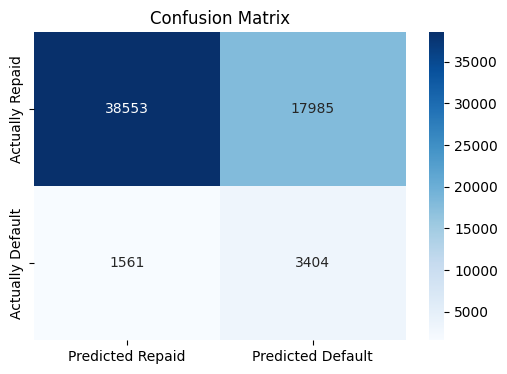

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Put the model in 'Evaluation Mode' (turns off the Dropout layers)
model.eval()

# 2. Make predictions on the hidden Test Set
# We use torch.no_grad() because we don't want the model to learn from the test!
with torch.no_grad(): 
    test_predictions = model(X_test_tensor)

# 3. Convert probabilities (0.0 to 1.0) into Yes/No (1 or 0)
# If the AI is more than 50% sure they will default, we flag them as a 1.
# Change the 0.5 to 0.08 (which roughly matches our 8% base risk rate)
predictions_binary = (test_predictions >= 0.08).float()

# 4. Generate the Report Card
print("--- FINAL EXAM RESULTS ---\n")
print(classification_report(y_test_tensor, predictions_binary, target_names=['Repaid (0)', 'Defaulted (1)']))

# 5. Visualize the mistakes (Confusion Matrix)
cm = confusion_matrix(y_test_tensor, predictions_binary)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Repaid', 'Predicted Default'], 
            yticklabels=['Actually Repaid', 'Actually Default'])
plt.title('Confusion Matrix')
plt.show()